In [48]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as pth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp
import pickle as pk


import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [49]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'COHERENCIA'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [50]:
img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = list(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*06days*.hdr'))

Estraggo i poligoni dei campi

In [51]:
mypoly = { }


for file in shapes:

    file_stem = Path(file).stem
    poly = Functions.open_shp(file)

    if poly is not None:
        
        poly_utm_list = Functions.cambio_coord(poly)
        
        mypoly[file_stem] = {
            'coord': poly_utm_list, # Salva la lista di pezzi
            'path': [pth.Path(p) for p in poly_utm_list] # Lista di oggetti Path
        }
    else:
        print(f"Salto il file {file} perché non è valido.")
        
    #print(f"Il poligono ha {len(mypoly[file_stem]['coord'])} pezzi.")

print(len(mypoly.keys()))

27


Reading SAR geographical coordinates

In [52]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

for key in mypoly:

    # 1. Trova il Bounding Box totale unendo tutti i pezzi del campo
    # Stack di tutti i pezzi per calcolare min/max globali

    all_coords = np.vstack(mypoly[key]['coord'])
    xmin, ymin = all_coords.min(axis=0)
    xmax, ymax = all_coords.max(axis=0)

    # 2. Trova gli indici nell'immagine Sentinel
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    # 3. Crea la griglia di punti per il ritaglio (Subset)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1

    X_sub = X_geo[c0:c1]
    Y_sub = Y_geo[r0:r1]
    
    # 4. Creazione maschera migliorata
    X_grid, Y_grid = np.meshgrid(X_sub, Y_sub)
    # Importante: usiamo stack per avere coppie (x, y) pulite
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

    mymask_sub = np.zeros(X_grid.shape, dtype=bool)
    # Cicla su ogni oggetto Path nella lista salvata precedentemente
    for pth_obj in mypoly[key]['path']:
        # Crea la maschera per il singolo pezzo e uniscila con l'OR logico (|)
        # Usiamo order='C' (standard) e poi .reshape()
        current_part_mask = pth_obj.contains_points(points).reshape(X_grid.shape)
        mymask_sub |= current_part_mask

    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    mypoly[key]['mask_sub'] =  mask_eroted #mymask_sub
    mypoly[key]['r_range'] = (r0, r1)
    mypoly[key]['c_range'] = (c0, c1)

# Debug finale
field = 'AKW-G1_C'
print(f"Index of starting column for {field}: {mypoly[field]['c_range'][0]}")
print(f"Shape of eroted mask: {mypoly[field]['mask_sub'].shape}")

Index of starting column for AKW-G1_C: 5240
Shape of eroted mask: (33, 35)


In [53]:
#df = pd.DataFrame(mypoly).T
#display(df)
#df.to_csv(f'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/polygons_geo.csv', index=True)

ReadingSAR images and saving the average and the std in a dictionary:
poly_stats[name_polygon][data+VV/VH][avg/std]

In [54]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assumendo formato YYYYMMDD
    
    # 1. Apriamo il file (senza caricarlo in RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determiniamo la polarizzazione dal nome del file
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. LEGGIAMO SOLO IL RITAGLIO DAL DISCO
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Pulizia dimensioni (da (H, W, 1) a (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Applichiamo la maschera erosa
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Calcolo in lineare
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Salvataggio (puoi aggiungere anche la conversione in dB qui)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Attenzione: nessun pixel valido per {key} in {file_stem}")

# Pulizia manuale della memoria alla fine di ogni file (opzionale)

del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [55]:
print(poly_stats['AKW_A_C']['20170104_VH'])

{'mean': np.float32(0.79114527), 'std': np.float32(0.047152907)}


In [56]:
Nme_types = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Name_Type.csv',
                         header=0)


Dataframe with statistics

In [57]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        row = {'ROI': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
df_stats = df_stats.merge(Nme_types, on='ROI', how='left')
display(df_stats)

,ROI,Date_Band,mean,std,Date,Band,Type
0,DB_A_C,20170104_VH,0.846021,0.060364,2017-01-04,VH,Aardappelen
1,DB_A_C,20170104_VV,0.912519,0.032522,2017-01-04,VV,Aardappelen
2,DB_A_C,20170110_VH,0.470780,0.095106,2017-01-10,VH,Aardappelen
3,DB_A_C,20170110_VV,0.660484,0.081345,2017-01-10,VV,Aardappelen
4,DB_A_C,20170116_VH,0.311812,0.113724,2017-01-16,VH,Aardappelen
...,...,...,...,...,...,...,...
3019,DB_SB1_C,20171212_VV,0.191203,0.106592,2017-12-12,VV,Bieten
3020,DB_SB1_C,20171218_VH,0.916552,0.026221,2017-12-18,VH,Bieten
3021,DB_SB1_C,20171218_VV,0.957047,0.016386,2017-12-18,VV,Bieten
3022,DB_SB1_C,20171224_VH,0.895575,0.024988,2017-12-24,VH,Bieten


Visualizing the mask of a polygon and the mean value

0.37091622


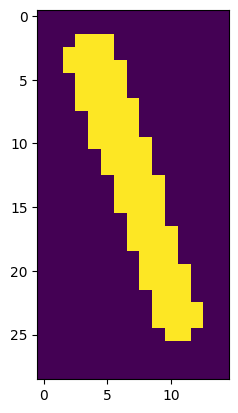

In [58]:
print(poly_stats['KL_MA_1_C']['20170305_VV']['mean'])
plt.imshow(mypoly['KL_MA_1_C']['mask_sub'])

(6346, 7025)



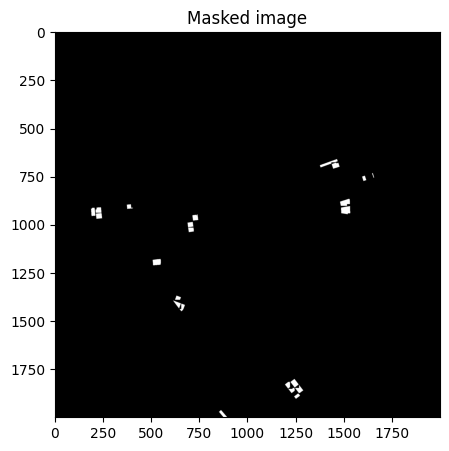

In [59]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_, IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(5,5))
plt.imshow(full_mask[1000:3000,4000:6000], cmap='gray')
plt.title("Masked image")
plt.show()

Uploading the file with the rain time series
(#https://sensoto.io/en/data/?c=5.518613%2C52.454220&z=10.03&te=2017-01-01T00%3A00%3A00.000Z%2C2017-12-31T23%3A59%3A59.999Z&tz=B&sid=open%24ghcn-hourly%24fru77206001%24precipitation%2Copen%24ghcn%24nle00152489%24prcp%2Copen%24ghcn%24nle00109000%24prcp&v=chart)

In [60]:
df_rainfall = pd.read_parquet(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/rainfall_total.parquet')
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

Check when is the first date of the SAR data

In [61]:
prima_corrispondenza = next((d for d in df_rainfall.index if np.datetime64(d) == img_dates[0]), None)

print(f"Data trovata: {prima_corrispondenza}")

Data trovata: 2017-01-04 00:00:00


In [62]:
df_filtered = df_rainfall.loc[prima_corrispondenza:]
print(df_filtered)

            prec_mm
date               
2017-01-04      4.3
2017-01-05      0.1
2017-01-06      5.9
2017-01-07      2.1
2017-01-08      0.2
...             ...
2018-01-08      0.0
2018-01-09      0.0
2018-01-10      2.9
2018-01-11      0.3
2018-01-12      0.6

[374 rows x 1 columns]


Weekly resampling (every 6 days)

In [63]:
df_weekly = df_filtered.resample('6D', label='left').sum()

GRAFICI DELLE STATISTICHE

In [64]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_ROI_Coherence_new.pdf'

with PdfPages(pdf_filename) as pdf:
    unique_rois = df_stats['ROI'].unique()

    for (roi, roi_type), group in df_stats.groupby(['ROI', 'Type']):
        # 1. Prepariamo la figura e gli assi
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Filtriamo i dati ROI
        roi_data = df_stats[df_stats['ROI'] == roi]
        
        
        # --- SICUREZZA DATE ---
        # Filtriamo le piogge per mostrare solo lo stesso periodo della coerenza
        min_date = roi_data['Date'].min()
        max_date = roi_data['Date'].max()
        rain_filtered = df_weekly[(df_weekly.index >= min_date) & (df_weekly.index <= max_date)]

        # --- ASSE 2: PIOGGIA (Sotto le linee) ---
        ax2 = ax1.twinx()
        # Usiamo zorder=1 per metterlo sullo sfondo
        ax2.bar(rain_filtered.index, rain_filtered.iloc[:,0], 
                color='skyblue', alpha=0.3, label='Rainfall (mm)', width=0.8, zorder=1)
        
        ax2.set_ylabel("Rainfall (mm)", color='tab:blue', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        
        # Spazio sopra le barre per non coprire le linee (regola il moltiplicatore se serve)
        if not rain_filtered.empty and rain_filtered.iloc[:,0].max() > 0:
            ax2.set_ylim(0, rain_filtered.iloc[:,0].max() * 2.5)
        ax2.invert_yaxis() 

        # --- ASSE 1: COERENZA (Sopra le barre) ---
        # Portiamo ax1 davanti a ax2
        ax1.set_zorder(ax2.get_zorder() + 1)
        ax1.patch.set_visible(False) # Rende ax1 trasparente per vedere ax2 sotto
        
        for band in roi_data['Band'].unique():
            band_data = roi_data[roi_data['Band'] == band]
            line, = ax1.plot(band_data['Date'], band_data['mean'], 
                             marker='o', markersize=4, linestyle='-', linewidth=2, 
                             label=f'Mean {band}', zorder=3)
            
            ax1.fill_between(
                band_data['Date'], 
                band_data['mean'] - band_data['std'], 
                band_data['mean'] + band_data['std'], 
                color=line.get_color(), 
                alpha=0.1, zorder=2
            )

        ax1.set_ylabel("Coherence", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Data", fontsize=12)
        ax1.set_ylim(0, 1.1) # La coerenza di solito sta tra 0 e 1

        # --- LEGENDA E LAYOUT ---
        # Uniamo le labels di entrambi gli assi
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        
        # Spostiamo la legenda leggermente più a destra e usiamo subplots_adjust
        ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.08, 1), borderaxespad=0.)

        plt.title(f"ROI: {roi} ({roi_type})- Coherence vs Rainfall", fontsize=14, pad=20)
        ax1.grid(True, linestyle='--', alpha=0.4)
        
        # Ruotiamo le date sull'asse X
        plt.setp(ax1.get_xticklabels(), rotation=45)
        
        # Invece di tight_layout puro, usiamo margin per far spazio alla legenda
        plt.subplots_adjust(right=0.85, bottom=0.15)
        
        pdf.savefig(fig)
        plt.close(fig)